In [1]:
import torch
import torch.nn.functional as F
import numpy as np
import timeit
import matplotlib.pyplot as plt
import torch.nn as nn
import random
from dreal import *
from matplotlib import cm
import math


In [2]:

torch.cuda.empty_cache()
torch.manual_seed(42)
random.seed()

device = torch.device("cuda:1" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
numerical_x = torch.Tensor(500, 2).uniform_(-6, 6).float().to(device)


Using device: cpu


In [3]:

# ---------------------------------------------------------------------
# dReal constraint checker
# ---------------------------------------------------------------------
def checkSMTconstraints(vars, a_learnt, divergence_learnt, ball_lb, ball_ub, config, epsilon=0):
    ball = Expression(0)
    for i in range(len(vars)):
        ball += vars[i]**2
    ball_in_bound = logical_and(ball >= ball_lb, ball <= ball_ub)
    a_condition = a_learnt >= 0
    divergence_condition = divergence_learnt > 0
    stability_condition = logical_and(
        logical_imply(ball_in_bound, divergence_condition),
        logical_imply(ball_in_bound, a_condition)
    )
    return CheckSatisfiability(logical_not(stability_condition), config)

# ---------------------------------------------------------------------
# Add counterexamples (unchanged)
# ---------------------------------------------------------------------
def AddCounterexamples(x, CE, N, device):
    # Detach x from the computational graph to avoid gradient issues
    x = x.detach()
    
    nearby = []
    for i in range(CE.size()):
        lb = CE[i].lb()
        ub = CE[i].ub()
        nearby_ = np.random.uniform(lb, ub, N)
        nearby.append(nearby_)

    for i in range(N):
        n_pt = [nearby[j][i] for j in range(x.shape[1])]
        n_pt_tensor = torch.tensor([n_pt], dtype=torch.float32, device=device)
        x = torch.cat((x, n_pt_tensor), dim=0)
        x = torch.unique(x, dim=0)
    return x, n_pt_tensor


In [4]:

# ---------------------------------------------------------------------
# Network classes
# ---------------------------------------------------------------------
class polynomial_net(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(polynomial_net, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, output_dim)
        )
        self._initialize_weights()
    def _initialize_weights(self):
        for layer in self.net:
            if isinstance(layer, nn.Linear):
                nn.init.xavier_uniform_(layer.weight)
                nn.init.zeros_(layer.bias)
    def forward(self, x):
        return self.net(x)

class polynomial_net_bias_Zero(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(polynomial_net_bias_Zero, self).__init__()
        layers = []
        for _ in range(5):
            layers += [nn.Linear(hidden_dim if layers else input_dim, hidden_dim), nn.Tanh()]
        layers.append(nn.Linear(hidden_dim, output_dim))
        self.net = nn.Sequential(*layers)
        self._initialize_weights()
    def _initialize_weights(self):
        for layer in self.net:
            if isinstance(layer, nn.Linear):
                nn.init.xavier_uniform_(layer.weight)
                nn.init.zeros_(layer.bias)
                layer.bias.requires_grad = False
    def forward(self, x):
        return self.net(x)

class numerator_polynomial_net(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(numerator_polynomial_net, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.Sigmoid(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Sigmoid(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Sigmoid(),
            nn.Linear(hidden_dim, output_dim),
            nn.Sigmoid()
        )
        self._initialize_weights()
    def _initialize_weights(self):
        for layer in self.net:
            if isinstance(layer, nn.Linear):
                nn.init.xavier_uniform_(layer.weight)
                nn.init.zeros_(layer.bias)
    def forward(self, x):
        return self.net(x)

class GammaFunctionNet(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(GammaFunctionNet, self).__init__()
        self.linear_layer = nn.Linear(input_dim, output_dim)
        nn.init.constant_(self.linear_layer.weight, 0)
        nn.init.constant_(self.linear_layer.bias, 0)
        self.linear_layer.weight.requires_grad = False
    def forward(self, x):
        return abs(self.linear_layer.bias.expand(x.shape[0], 1))


In [5]:

# ---------------------------------------------------------------------
# System definition f(x), g(x)
# ---------------------------------------------------------------------
def f(x):
    return torch.stack([
        -2*x[..., 0] + x[..., 0]**2 - x[..., 1]**2,
        -6*x[..., 1] + 2*x[..., 0]*x[..., 1]
    ], dim=-1)

def g(x):
    return torch.zeros_like(x)

def div_f(x):
    return 4*x[..., 0] - 8

def div_g(x):
    return torch.zeros(x.shape[0], device=x.device)

# ---------------------------------------------------------------------
# Vectorized control density loss and risk
# ---------------------------------------------------------------------
def control_density_risk(x, f_fun, g_fun, a_fun, b_fun, c_fun):
    x.requires_grad_(True)
    f_vals = f_fun(x)
    g_vals = g_fun(x)
    divf_vals = div_f(x)
    divg_vals = div_g(x)

    a_vals = a_fun(x)
    c_vals = c_fun(x)
    b_vals = b_fun(x)

    # grad a, c (each batch × 2)
    grad_a = torch.autograd.grad(a_vals.sum(), x, create_graph=True)[0]
    grad_c = torch.autograd.grad(c_vals.sum(), x, create_graph=True)[0]

    # grad_b of ||b||²
    b_norm_sq = (b_vals ** 2).sum(dim=1)
    grad_b = torch.autograd.grad(b_norm_sq.sum(), x, create_graph=True)[0]

    term1 = a_vals.squeeze() * divf_vals + divg_vals * c_vals.squeeze() \
            + (grad_a * f_vals).sum(dim=1) + (grad_c * g_vals).sum(dim=1)
    term2 = ((2*x + grad_b) * (f_vals * a_vals + g_vals * c_vals)).sum(dim=1)
    return term1 - term2

def control_density_loss(x, f_fun, g_fun, a_fun, b_fun, c_fun, gamma_fun):
    divergence = control_density_risk(x, f_fun, g_fun, a_fun, b_fun, c_fun)
    loss = F.relu(gamma_fun(x).squeeze() - divergence).mean()
    a_loss = F.relu(-a_fun(x)).mean()
    gamma_loss = F.relu(-gamma_fun(x)).mean()
    return loss + a_loss + gamma_loss


In [6]:
class activSymbolicNN:
    """
    A helper class to convert neural networks to symbolic expressions for dReal.
    """
    def __init__(self, net):
        """Initialize with a PyTorch neural network"""
        self.weights = []
        self.biases = []
        self.extract_params(net)

    def extract_params(self, net):
        """Extract weights and biases from PyTorch network"""
        for layer in net.net:
            if isinstance(layer, nn.Linear):
                self.weights.append(layer.weight.detach().cpu().numpy())
                if layer.bias is not None:
                    self.biases.append(layer.bias.detach().cpu().numpy())

    def forward_symbolic(self, vars):
        """
        Compute symbolic forward pass.
        Args:
            vars: List of dReal Variables
        Returns:
            Symbolic expression for network output
        """
        z = vars
        for i in range(len(self.weights)):
            # Linear transformation
            z = self._linear_symbolic(z, self.weights[i], self.biases[i])
            # # Apply tanh activation
            # z = [tanh(zi) for zi in z]
            # Apply sigmoid activation
            z = [(1/(1 + exp(-zi))) for zi in z]
        
        # # Final linear layer without activation
        # z = self._linear_symbolic(z, self.weights[-1], self.biases[-1])
        return z

    def _linear_symbolic(self, x, weight, bias):
        """
        Compute symbolic linear transformation.
        Args:
            x: Input symbolic expressions
            weight: Weight matrix
            bias: Bias vector
        Returns:
            List of symbolic expressions
        """
        out = []
        for i in range(weight.shape[0]):  # For each output dimension
            expr = bias[i]
            for j in range(weight.shape[1]):  # For each input dimension
                expr += weight[i,j] * x[j]
            out.append(expr)
        return out


In [7]:
class SymbolicNN:
    """
    A helper class to convert neural networks to symbolic expressions for dReal.
    """
    def __init__(self, net):
        """Initialize with a PyTorch neural network"""
        self.weights = []
        self.biases = []
        self.extract_params(net)

    def extract_params(self, net):
        """Extract weights and biases from PyTorch network"""
        for layer in net.net:
            if isinstance(layer, nn.Linear):
                self.weights.append(layer.weight.detach().cpu().numpy())
                if layer.bias is not None:
                    self.biases.append(layer.bias.detach().cpu().numpy())

    def forward_symbolic(self, vars):
        """
        Compute symbolic forward pass.
        Args:
            vars: List of dReal Variables
        Returns:
            Symbolic expression for network output
        """
        z = vars
        for i in range(len(self.weights) - 1):
            # Linear transformation
            z = self._linear_symbolic(z, self.weights[i], self.biases[i])
            # Apply tanh activation
            z = [tanh(zi) for zi in z]
            # # Apply sigmoid activation
            # z = [(1/(1 + exp(-zi))) for zi in z]
        
        # Final linear layer without activation
        z = self._linear_symbolic(z, self.weights[-1], self.biases[-1])
        return z

    def _linear_symbolic(self, x, weight, bias):
        """
        Compute symbolic linear transformation.
        Args:
            x: Input symbolic expressions
            weight: Weight matrix
            bias: Bias vector
        Returns:
            List of symbolic expressions
        """
        out = []
        for i in range(weight.shape[0]):  # For each output dimension
            expr = bias[i]
            for j in range(weight.shape[1]):  # For each input dimension
                expr += weight[i,j] * x[j]
            out.append(expr)
        return out


In [8]:
def candidate_constraint_learnt(vars,a_fun,b_fun,c_fun):
    """
    Construct candidate constraints for the learnt functions.
    
    Args:
        vars: List of dReal Variables
        a_fun: Function representing a(x).
        b_fun: Function representing b(x).
        c_fun: Function representing c(x).

    Returns:
        Symbolic expression for the candidate constraint.
    """
    a_sym = activSymbolicNN(a_fun).forward_symbolic(vars)[0]
    b_sym = SymbolicNN(b_fun).forward_symbolic(vars)
    c_sym = SymbolicNN(c_fun).forward_symbolic(vars)[0]

    # b_sym = ||b_sym||^2
    b_sym = sum([bi**2 for bi in b_sym])
    # write f and g in terms of val
    f_val = [-2*vars[0]+vars[0]**2 - vars[1]**2, -6*vars[1]+2*vars[0]*vars[1]]
    # print("f_val: ", f_val)
    g_val = [0*vars[0],0*vars[0]]
    # print("g_val: ", g_val)
    f_div = 4*vars[0]-8
    g_div = 0 
    grad_a = [a_sym.Differentiate(vars[i]) for i in range(len(vars))]
    grad_c = [c_sym.Differentiate(vars[i]) for i in range(len(vars))]
    grad_b = [b_sym.Differentiate(vars[i]) for i in range(len(vars))]

    constraint1 = a_sym * f_div + g_div * c_sym + sum([grad_a[i] * f_val[i] for i in range(len(f_val))]) + sum([grad_c[i] * g_val[i] for i in range(len(g_val))])
  
    scaled_vars = [2 * var_i for var_i in vars]
    constraint2 = [scaled_vars[i] + grad_b[i] for i in range(len(vars))]

    constraint2 = sum([constraint2[i] * (f_val[i] * a_sym + g_val[i] * c_sym) for i in range(len(f_val))])  
    constraint = constraint1 - constraint2
    return a_sym , constraint


In [9]:
config = Config()
config.use_polytope_in_forall = True
config.use_local_optimization = True
config.precision = 1e-5
epsilon = 0

ball_lb = 0.5
ball_ub = 6
x1 = Variable("x1")
x2 = Variable("x2")


In [10]:


# ---------------------------------------------------------------------
# Training
# ---------------------------------------------------------------------
def train_density(x, epochs=2000, lr=1e-2):
    loss_total_density = []
    a_net = numerator_polynomial_net(2, 1, 1).to(device)
    c_net = polynomial_net(2, 1, 1).to(device)
    b_net = polynomial_net_bias_Zero(2, 2, 2).to(device)
    gamma_net = GammaFunctionNet(2, 1).to(device)

    optimizer = torch.optim.Adam(
        list(a_net.parameters()) + list(c_net.parameters()) + 
        list(b_net.parameters()) + list(gamma_net.parameters()), lr=lr
    )

    config = Config()
    config.use_polytope_in_forall = True
    config.use_local_optimization = True
    config.precision = 1e-5
    epsilon = 0
    ball_lb, ball_ub = 0.5, 6

    valid = False
    print("Training density function")
    while not valid:
        for epoch in range(epochs):
            optimizer.zero_grad()
            loss = control_density_loss(x, f, g, a_net, b_net, c_net, gamma_net)
            loss_total_density.append(loss.item())
            loss.backward()
            optimizer.step()

            print(f"Epoch {epoch}/{epochs}, Loss: {loss.item():.4f}")
            if loss.item() < 3e-4:
                valid = True
                print("No counterexample found.")
                break

            
            if epoch % 1000 == 0:
                # Check for counterexamples
                vars = [Variable("x1"), Variable("x2")]
                a_learnt, divergence_learnt = candidate_constraint_learnt(vars, a_net, b_net, c_net)
                CE = checkSMTconstraints(vars, a_learnt, divergence_learnt, ball_lb, ball_ub, config)
                if (CE):
                    print("Counterexample found!")
                    x, n_pt_tensor = AddCounterexamples(x, CE, 100, device)
                else:
                    valid = True 
                    print("No counterexample found.")
                    break
                
    print(f"Final Loss: {loss.item():.4f}")
    print(f"Learned margin: {gamma_net(torch.zeros(1,2,device=device))}")
    return loss_total_density, a_net, b_net, c_net, gamma_net

def plot_results(risks, labels):
    plt.figure(figsize=(10,6))
    for risk, label in zip(risks, labels):
        plt.plot(risk, label=label)
    plt.xlabel("Iteration")
    plt.ylabel("Risk")
    plt.legend()
    plt.grid()
    plt.show()



In [22]:
# ---------------------------------------------------------------------
# Run training
# ---------------------------------------------------------------------
loss_density, a_ret, b_ret, c_ret, gamma_net = train_density(numerical_x, epochs=4000, lr=1e-3)

Training density function
Epoch 0/4000, Loss: 10.5583
Counterexample found!
Epoch 1/4000, Loss: 8.8107
Epoch 2/4000, Loss: 8.8027
Epoch 3/4000, Loss: 8.7947
Epoch 4/4000, Loss: 8.7867
Epoch 5/4000, Loss: 8.7786
Epoch 6/4000, Loss: 8.7705
Epoch 7/4000, Loss: 8.7624
Epoch 8/4000, Loss: 8.7543
Epoch 9/4000, Loss: 8.7462
Epoch 10/4000, Loss: 8.7380
Epoch 11/4000, Loss: 8.7298
Epoch 12/4000, Loss: 8.7216
Epoch 13/4000, Loss: 8.7133
Epoch 14/4000, Loss: 8.7050
Epoch 15/4000, Loss: 8.6966
Epoch 16/4000, Loss: 8.6882
Epoch 17/4000, Loss: 8.6798
Epoch 18/4000, Loss: 8.6713
Epoch 19/4000, Loss: 8.6627
Epoch 20/4000, Loss: 8.6541
Epoch 21/4000, Loss: 8.6454
Epoch 22/4000, Loss: 8.6367
Epoch 23/4000, Loss: 8.6281
Epoch 24/4000, Loss: 8.6194
Epoch 25/4000, Loss: 8.6107
Epoch 26/4000, Loss: 8.6019
Epoch 27/4000, Loss: 8.5931
Epoch 28/4000, Loss: 8.5842
Epoch 29/4000, Loss: 8.5753
Epoch 30/4000, Loss: 8.5664
Epoch 31/4000, Loss: 8.5574
Epoch 32/4000, Loss: 8.5484
Epoch 33/4000, Loss: 8.5394
Epoch 34/

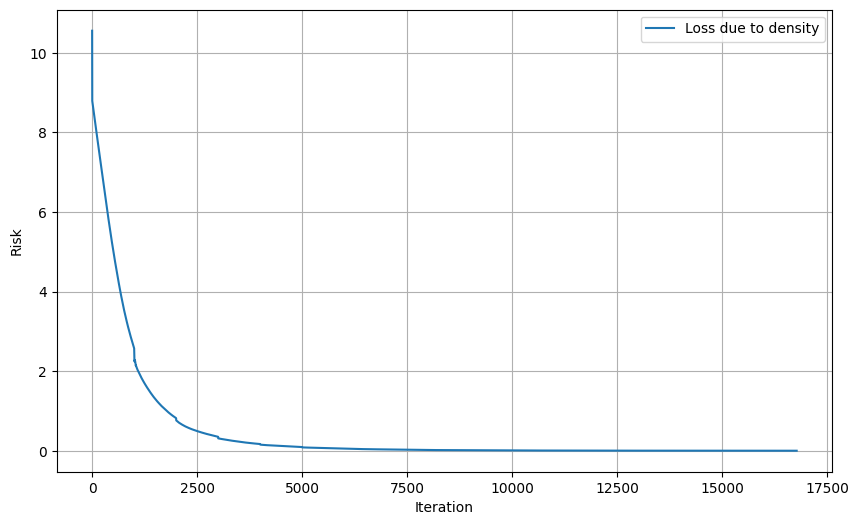

In [23]:

risks = []
risks.append(loss_density)

plot_results(risks, labels=[f"Loss due to {d}" for d in ['density']])


In [24]:
grid_size = 100
# Define grid for x1 and x2
x1 = torch.linspace(-6, 6, grid_size)
x2 = torch.linspace(-6, 6, grid_size)
x1_grid, x2_grid = torch.meshgrid(x1, x2)
grid_points = torch.stack([x1_grid.ravel(), x2_grid.ravel()], dim=1).to(device)


/home/sahilc/miniconda3/envs/dreal_env/lib/python3.8/site-packages/torch/functional.py:513: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at ../aten/src/ATen/native/TensorShape.cpp:3609.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


In [25]:
rho_set = a_ret(grid_points)/ (torch.exp( torch.sum(grid_points**2, dim=1, keepdim=True) + torch.sum((b_ret(grid_points))**2, dim=1, keepdim=True)))


# # Compute violations set: element-wise min of rho_set and divergence_set
# violations_set = torch.minimum(rho_set, divergence_set)
violations_set = rho_set
# # Convert to binary values: 1 for violation, -1 for satisfaction
# violations_set = torch.where(violations_set <= 0, 1, -1)

# Move to CPU and convert to NumPy for visualization
violations_set = violations_set.detach().cpu().numpy().reshape(grid_size, grid_size)


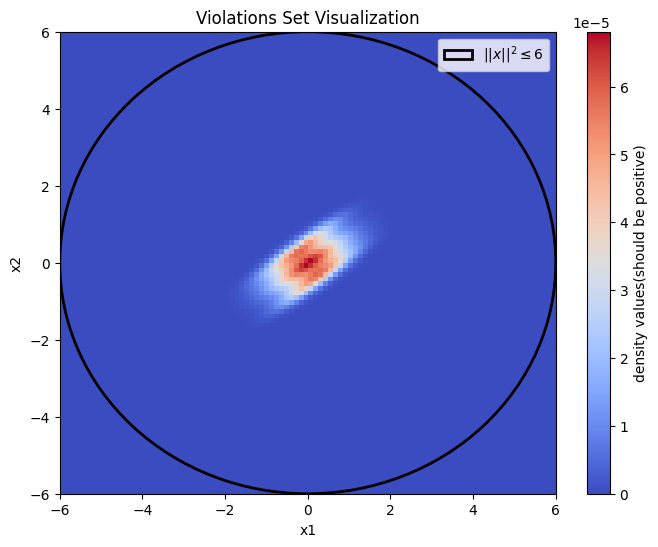

In [26]:
import matplotlib.patches as patches

# Plot heatmap
plt.figure(figsize=(8, 6))
plt.imshow(
    violations_set,
    extent=[-6, 6, -6, 6],
    origin='lower',
    cmap='coolwarm',
    aspect='auto'
)
plt.colorbar(label="density values(should be positive)")
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Violations Set Visualization")

# Add a circle to the plot
circle = patches.Circle((0, 0), 6, color='black', fill=False, linewidth=2, label="$||x||^2 \leq 6$")
plt.gca().add_patch(circle)

# Add legend for the circle
plt.legend(loc='upper right')

plt.grid(False)
plt.show()


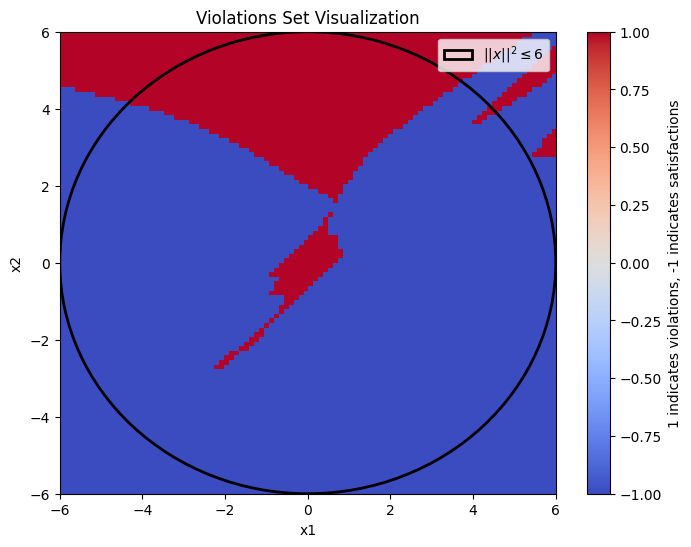

In [27]:
divergence_set = control_density_risk(grid_points, f, g, a_ret, b_ret, c_ret)

violations_set = divergence_set
# # Convert to binary values: 1 for violation, -1 for satisfaction
violations_set = torch.where(violations_set <= 0, 1, -1)

# Move to CPU and convert to NumPy for visualization
violations_set = violations_set.detach().cpu().numpy().reshape(grid_size, grid_size)




import matplotlib.patches as patches

# Plot heatmap
plt.figure(figsize=(8, 6))
plt.imshow(
    violations_set,
    extent=[-6, 6, -6, 6],
    origin='lower',
    cmap='coolwarm',
    aspect='auto'
)
plt.colorbar(label="1 indicates violations, -1 indicates satisfactions")
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Violations Set Visualization")

# Add a circle to the plot
circle = patches.Circle((0, 0), 6, color='black', fill=False, linewidth=2, label="$||x||^2 \leq 6$")
plt.gca().add_patch(circle)

# Add legend for the circle
plt.legend(loc='upper right')

plt.grid(False)
plt.show()


In [28]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm

In [29]:
torch.save(a_ret.state_dict(), 'learnt_a_control_density_example_5.pth')
torch.save(b_ret.state_dict(), 'learnt_b_control_density_example_5.pth')
torch.save(c_ret.state_dict(), 'learnt_c_control_density_example_5.pth')

In [30]:
# get some fresh data 
torch.manual_seed(7)
random.seed()
numerical_x = torch.Tensor(1000, 2).uniform_(-6, 6).float()
numerical_x = numerical_x.to(device)

loss_density, a_ret, b_ret, c_ret, gamma_net = train_density(numerical_x, epochs=4000, lr=1e-3)

Training density function
Epoch 0/4000, Loss: 9.2503
Counterexample found!
Epoch 1/4000, Loss: 8.8163
Epoch 2/4000, Loss: 8.8060
Epoch 3/4000, Loss: 8.7957
Epoch 4/4000, Loss: 8.7853
Epoch 5/4000, Loss: 8.7750
Epoch 6/4000, Loss: 8.7647
Epoch 7/4000, Loss: 8.7544
Epoch 8/4000, Loss: 8.7441
Epoch 9/4000, Loss: 8.7337
Epoch 10/4000, Loss: 8.7234
Epoch 11/4000, Loss: 8.7131
Epoch 12/4000, Loss: 8.7028
Epoch 13/4000, Loss: 8.6924
Epoch 14/4000, Loss: 8.6821
Epoch 15/4000, Loss: 8.6718
Epoch 16/4000, Loss: 8.6614
Epoch 17/4000, Loss: 8.6511
Epoch 18/4000, Loss: 8.6408
Epoch 19/4000, Loss: 8.6304
Epoch 20/4000, Loss: 8.6201
Epoch 21/4000, Loss: 8.6097
Epoch 22/4000, Loss: 8.5994
Epoch 23/4000, Loss: 8.5890
Epoch 24/4000, Loss: 8.5787
Epoch 25/4000, Loss: 8.5684
Epoch 26/4000, Loss: 8.5580
Epoch 27/4000, Loss: 8.5477
Epoch 28/4000, Loss: 8.5373
Epoch 29/4000, Loss: 8.5270
Epoch 30/4000, Loss: 8.5166
Epoch 31/4000, Loss: 8.5062
Epoch 32/4000, Loss: 8.4959
Epoch 33/4000, Loss: 8.4855
Epoch 34/4

In [31]:
torch.save(a_ret.state_dict(), 'learnt_a_control_density1_example_5.pth')
torch.save(b_ret.state_dict(), 'learnt_b_control_density1_example_5.pth')
torch.save(c_ret.state_dict(), 'learnt_c_control_density1_example_5.pth')

In [11]:
# Define Model dimensions
INPUT_DIM = 2 
HIDDEN_DIM_A = 1
HIDDEN_DIM_B = 2
HIDDEN_DIM_C = 1

# Output dimension
A_OUTPUT_DIM = 1
B_OUTPUT_DIM = 2
C_OUTPUT_DIM = 1


In [12]:
# LOAD THE TRAINED MODEL weights for u_1 and \rho_1
# LOAD THE TRAINED MODEL weights for u_1 and \rho_1

a_net = numerator_polynomial_net(INPUT_DIM, HIDDEN_DIM_A, A_OUTPUT_DIM).to(device)
# Add map_location
a_net.load_state_dict(torch.load('Model_Paths/learnt_a_control_density_example_5.pth', map_location=device))
a_net.eval()

b_net = polynomial_net_bias_Zero(INPUT_DIM, HIDDEN_DIM_B, B_OUTPUT_DIM).to(device)
# Add map_location
b_net.load_state_dict(torch.load('Model_Paths/learnt_b_control_density_example_5.pth', map_location=device))
b_net.eval()

c_net = polynomial_net(INPUT_DIM, HIDDEN_DIM_C, C_OUTPUT_DIM).to(device)
# Add map_location
c_net.load_state_dict(torch.load('Model_Paths/learnt_c_control_density_example_5.pth', map_location=device))
c_net.eval()

# load the second model
a_net1 = numerator_polynomial_net(INPUT_DIM, HIDDEN_DIM_A, A_OUTPUT_DIM).to(device)
# Add map_location
a_net1.load_state_dict(torch.load('Model_Paths/learnt_a_control_density1_example_5.pth', map_location=device))
a_net1.eval()

b_net1 = polynomial_net_bias_Zero(INPUT_DIM, HIDDEN_DIM_B, B_OUTPUT_DIM).to(device)
# Add map_location
b_net1.load_state_dict(torch.load('Model_Paths/learnt_b_control_density1_example_5.pth', map_location=device))
b_net1.eval()

c_net1 = polynomial_net(INPUT_DIM, HIDDEN_DIM_C, C_OUTPUT_DIM).to(device)
# Add map_location
c_net1.load_state_dict(torch.load('Model_Paths/learnt_c_control_density1_example_5.pth', map_location=device))
c_net1.eval()


/tmp/ipykernel_9060/2226295014.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  a_net.load_state_dict(torch.load('Model_Paths/learnt_a_control_density_example_5.pth', map

polynomial_net(
  (net): Sequential(
    (0): Linear(in_features=2, out_features=1, bias=True)
    (1): Tanh()
    (2): Linear(in_features=1, out_features=1, bias=True)
    (3): Tanh()
    (4): Linear(in_features=1, out_features=1, bias=True)
    (5): Tanh()
    (6): Linear(in_features=1, out_features=1, bias=True)
  )
)

In [13]:
def plot_density_countours(a_nn, b_nn, c_nn,density_threshold, device, plot_flow=True):
    # create meshgrid
    x1 = torch.linspace(-6, 6, 100)
    x2 = torch.linspace(-6, 6, 100)
    X, Y = np.meshgrid(x1,x2)

    # Convert to torch tensor
    grid_points = torch.tensor(np.column_stack([X.ravel(), Y.ravel()]), dtype=torch.float32).to(device)

    # compute the modified density function
    with torch.no_grad():
        rho_set = a_nn(grid_points) / (torch.exp( torch.sum(grid_points**2, dim=1, keepdim=True) + torch.sum((b_nn(grid_points))**2, dim=1, keepdim=True)))
        rho_set = rho_set.squeeze()
        rho_set = rho_set.cpu().numpy().reshape(X.shape)
    # plot the density function
    fig, ax = plt.subplots(figsize=(8, 6))
    # contours = ax.contour(X, Y, rho_set, levels=10, colors='k')

    ax.contour(X,Y,rho_set-density_threshold,levels=0,colors='black', linewidths=2,linestyles='solid', label='Mixed Density')

    filled_contours = ax.contourf(X, Y, rho_set, levels=10, alpha=0.3, cmap=cm.coolwarm)
    plt.colorbar(filled_contours, label='Density Value')

    if plot_flow:
        # create coarser grid for flow field
        x1_flow = np.linspace(-6, 6, 20)
        x2_flow = np.linspace(-6, 6, 20)
        X_flow, Y_flow = np.meshgrid(x1_flow, x2_flow)
        flow_points = torch.tensor(np.column_stack([X_flow.ravel(), Y_flow.ravel()]), dtype=torch.float32).to(device)

        # evaluate control policy u
        with torch.no_grad():
            u_values = c_nn(flow_points) / a_nn(flow_points)
               
        # Calculate vector field
        DX = np.zeros_like(X_flow)
        DY = np.zeros_like(Y_flow)
        
        for i in range(len(x1_flow)):
            for j in range(len(x2_flow)):
                idx = i * len(x1_flow) + j
                x = torch.tensor([X_flow[i, j], Y_flow[i, j]], device=device)
                f_val = f(x)
                g_val = g(x)
                u = u_values[idx]
                
                # Compute flow: f(x) + g(x)u
                flow = f_val + g_val * u
                DX[i, j] = flow[0].cpu().numpy()
                DY[i, j] = flow[1].cpu().numpy()
        
        # Normalize vectors for better visualization
        magnitude = np.sqrt(DX**2 + DY**2)
        DX = DX / magnitude
        DY = DY / magnitude
        
        # Plot flow field
        ax.streamplot(X_flow, Y_flow, DX, DY, color='gray', linewidth=0.5,
                     density=1.0, arrowstyle='-|>', arrowsize=1.5)
    
    # Add valid region circle
    circle = plt.Circle((0, 0), 6, color='r', fill=False, linewidth=1.5, label='Valid Region')
    ax.add_artist(circle)
    
    # Customize plot
    ax.set_xlabel('x_1', fontsize=12)
    ax.set_ylabel('x_2', fontsize=12)
    ax.set_title('Example 5', fontsize=10, fontweight='bold')
    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], color='black', linewidth=2, linestyle='-', label='RoA due to learned density'),
        Line2D([0], [0], color='red', linewidth=2, linestyle='--', label='Valid Region')
    ]
    ax.legend(handles=legend_elements, loc='upper right', fontsize=11)
    
    
    
    plt.show()
    
    return fig, ax




    

/tmp/ipykernel_9060/1893008172.py:19: UserWarning: The following kwargs were not used by contour: 'label'
  ax.contour(X,Y,rho_set-density_threshold,levels=0,colors='black', linewidths=2,linestyles='solid', label='Mixed Density')


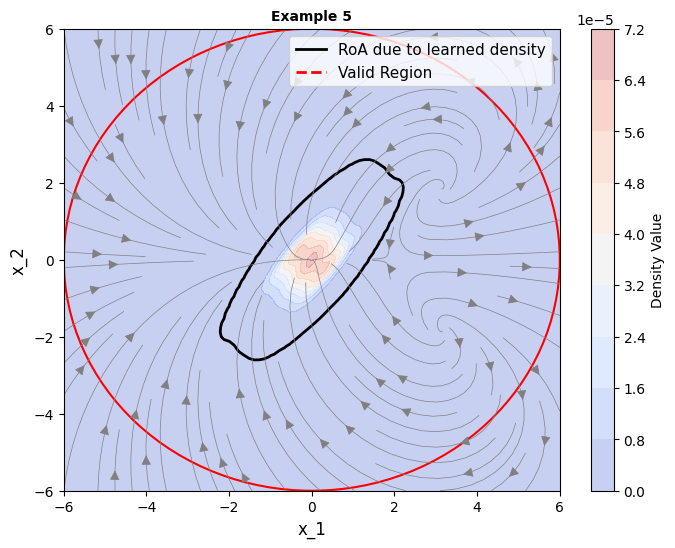

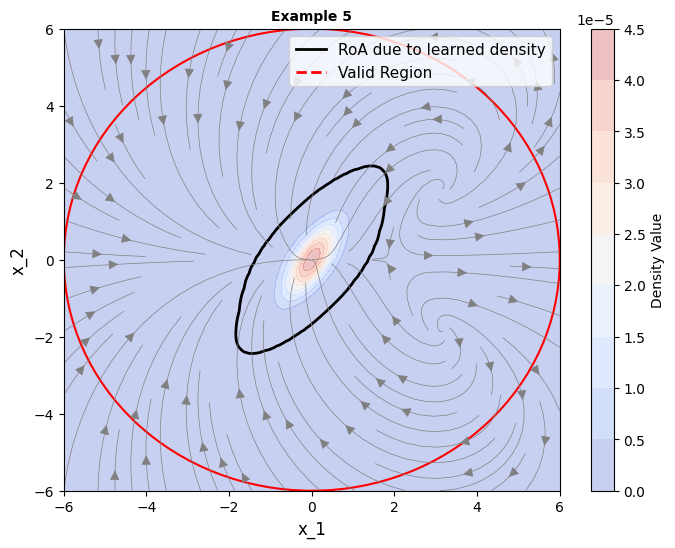

(<Figure size 800x600 with 2 Axes>,
 <Axes: title={'center': 'Example 5'}, xlabel='x_1', ylabel='x_2'>)

In [14]:

# Call the function to plot density contours and flow field
plot_density_countours(a_net, b_net, c_net,1e-8, device, plot_flow=True)


# Call the function to plot density contours and flow field
plot_density_countours(a_net1, b_net1, c_net1,1e-8, device, plot_flow=True)



/tmp/ipykernel_9060/458955219.py:21: UserWarning: The following kwargs were not used by contour: 'label'
  ax.contour(X,Y,rho_set-density_threshold,levels=0,colors='black', linewidths=2,linestyles='solid', label='Mixed Density')


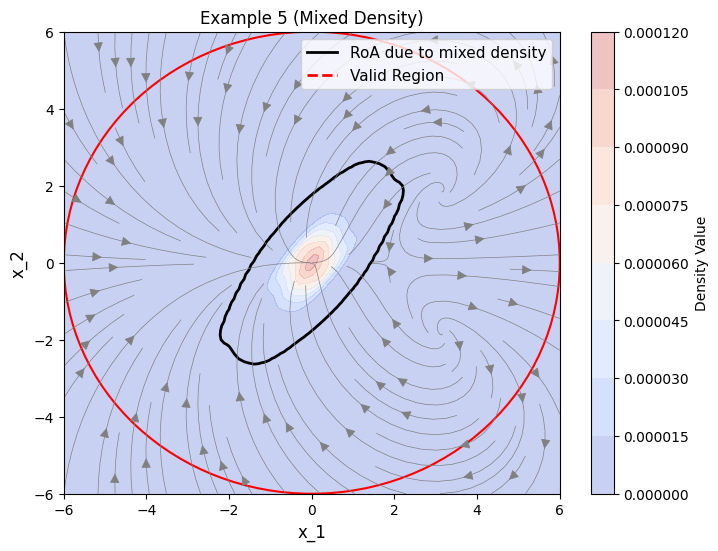

(<Figure size 800x600 with 2 Axes>,
 <Axes: title={'center': 'Example 5 (Mixed Density)'}, xlabel='x_1', ylabel='x_2'>)

In [15]:
def plot_mixed_density_countours(a_nn, b_nn, c_nn,a_nn1,b_nn1,c_nn1, density_threshold, device, plot_flow=True):
    # create meshgrid
    x1 = torch.linspace(-6, 6, 100)
    x2 = torch.linspace(-6, 6, 100)
    X, Y = np.meshgrid(x1,x2)

    # Convert to torch tensor
    grid_points = torch.tensor(np.column_stack([X.ravel(), Y.ravel()]), dtype=torch.float32).to(device)

    # compute the modified density function
    with torch.no_grad():
        rho_set1 = a_nn(grid_points) / (torch.exp( torch.sum(grid_points**2, dim=1, keepdim=True) + torch.sum((b_nn(grid_points))**2, dim=1, keepdim=True)))
        rho_set2 =  a_nn1(grid_points) / (torch.exp( torch.sum(grid_points**2, dim=1, keepdim=True) + torch.sum((b_nn1(grid_points))**2, dim=1, keepdim=True)))
        rho_set =  rho_set1+rho_set2
        rho_set = rho_set.squeeze()
        rho_set = rho_set.cpu().numpy().reshape(X.shape)
    # plot the density function
    fig, ax = plt.subplots(figsize=(8, 6))
    # contours = ax.contour(X, Y, rho_set, levels=10, colors='k')

    ax.contour(X,Y,rho_set-density_threshold,levels=0,colors='black', linewidths=2,linestyles='solid', label='Mixed Density')
    filled_contours = ax.contourf(X, Y, rho_set, levels=10, alpha=0.3, cmap=cm.coolwarm)
    plt.colorbar(filled_contours, label='Density Value')

    if plot_flow:
        # create coarser grid for flow field
        x1_flow = np.linspace(-6, 6, 20)
        x2_flow = np.linspace(-6, 6, 20)
        X_flow, Y_flow = np.meshgrid(x1_flow, x2_flow)
        flow_points = torch.tensor(np.column_stack([X_flow.ravel(), Y_flow.ravel()]), dtype=torch.float32).to(device)

        # evaluate control policy u
        with torch.no_grad():
            rho_set1 = a_nn(flow_points) / (torch.exp( torch.sum(flow_points**2, dim=1, keepdim=True) + torch.sum((b_nn(flow_points))**2, dim=1, keepdim=True)))
            
            rho_set2 =  a_nn1(flow_points) / (torch.exp( torch.sum(flow_points**2, dim=1, keepdim=True) + torch.sum((b_nn1(flow_points))**2, dim=1, keepdim=True)))
            u_values1 = c_nn(flow_points) / a_nn(flow_points)
            u_values2 = c_nn1(flow_points) / a_nn1(flow_points)
            weight1 = rho_set1 / (rho_set1+rho_set2)
            weight2 = rho_set2 / (rho_set1+rho_set2)
            u_values = weight1 * u_values1 + weight2 * u_values2
               
        # Calculate vector field
        DX = np.zeros_like(X_flow)
        DY = np.zeros_like(Y_flow)
        
        for i in range(len(x1_flow)):
            for j in range(len(x2_flow)):
                idx = i * len(x1_flow) + j
                x = torch.tensor([X_flow[i, j], Y_flow[i, j]], device=device)
                f_val = f(x)
                g_val = g(x)
                u = u_values[idx]
                
                # Compute flow: f(x) + g(x)u
                flow = f_val + g_val * u
                DX[i, j] = flow[0].cpu().numpy()
                DY[i, j] = flow[1].cpu().numpy()
        
        # Normalize vectors for better visualization
        magnitude = np.sqrt(DX**2 + DY**2)
        DX = DX / magnitude
        DY = DY / magnitude
        
        # Plot flow field
        ax.streamplot(X_flow, Y_flow, DX, DY, color='gray', linewidth=0.5,
                     density=1.0, arrowstyle='-|>', arrowsize=1.5)
    
    # Add valid region circle
    circle = plt.Circle((0, 0), 6, color='r', fill=False, linewidth=1.5, label='Valid Region')
    ax.add_artist(circle)
    
    # Customize plot
    ax.set_xlabel('x_1', fontsize=12)
    ax.set_ylabel('x_2', fontsize=12)
    ax.set_title('Example 5 (Mixed Density)')
    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], color='black', linewidth=2, linestyle='-', label='RoA due to mixed density'),
        Line2D([0], [0], color='red', linewidth=2, linestyle='--', label='Valid Region')
    ]
    ax.legend(handles=legend_elements, loc='upper right', fontsize=11)
    
    
    
    plt.show()
    
    return fig, ax


# Call the function to plot density contours and flow field
plot_mixed_density_countours(a_net, b_net, c_net,a_net1,b_net1,c_net1, 1e-8, device, plot_flow=True)



In [16]:
# -----------------------------------------------------------------
# --- New Code Block Starts Here ---
# -----------------------------------------------------------------

from matplotlib import cm # Ensure cm is imported at the top level

# --- 1. Helper functions for the Analytical Solution ---

def analytical_density(x, device, alpha=4.0, epsilon=1e-9):
    """
    Computes the analytical density rho(x) = 1 / (b(x)^alpha)
    x: torch.tensor of shape [N, 2]
    """
    x1 = x[:, 0]
    x2 = x[:, 1]
    
    # b(x) = 3*x1^2 + 2*x1*x2 + 2*x2^2
    b_val =  (x1**2) + (x2**2)
    
    # rho(x) = 1 / b(x)^alpha
    # Add epsilon for numerical stability at the origin
    rho = (1) / (torch.pow(b_val, alpha) + epsilon) 
    
    return rho.to(device)

def analytical_control(x, device):
    """
    Computes the analytical control policy u(x)
    x: torch.tensor of shape [N, 2]
    """
    x1 = x[:, 0]
    x2 = x[:, 1]
    
    # u(x) = -1.22*x1 - 0.57*x2 - 0.129*x2^3
    u_val = 0*x1 + 0*x2 # Zero control for this example
    
    return u_val.to(device)

# --- 2. Function to plot Analytical Density and Flow ---

def plot_analytical_density_and_flow(density_threshold,device, plot_flow=True):
    """
    Plots the contours of the analytical density and the flow field 
    of the analytical control policy.
    """
    # create meshgrid
    x1 = torch.linspace(-6, 6, 100)
    x2 = torch.linspace(-6, 6, 100)
    X, Y = np.meshgrid(x1,x2)
    
    # Convert to torch tensor
    grid_points = torch.tensor(np.column_stack([X.ravel(), Y.ravel()]), dtype=torch.float32).to(device)
    
    # compute the analytical density function
    with torch.no_grad():
        rho_set = analytical_density(grid_points, device)
        rho_set = rho_set.squeeze()
        rho_set = rho_set.cpu().numpy().reshape(X.shape)
        
    # plot the density function
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.contour(X,Y,rho_set-density_threshold,levels=0,colors='black', linewidths=2,linestyles='solid', label='Density due to lyapunov')
    filled_contours = ax.contourf(X, Y, rho_set, levels=20, alpha=0.5, cmap=cm.coolwarm) # More levels for analytical
    plt.colorbar(filled_contours, label='Analytical Density Value')
    
    if plot_flow:
        # create coarser grid for flow field
        x1_flow = np.linspace(-6, 6, 20)
        x2_flow = np.linspace(-6, 6, 20)
        X_flow, Y_flow = np.meshgrid(x1_flow, x2_flow)
        flow_points = torch.tensor(np.column_stack([X_flow.ravel(), Y_flow.ravel()]), dtype=torch.float32).to(device)
        
        # evaluate control policy u
        with torch.no_grad():
            u_values = analytical_control(flow_points, device)
                                
            # Calculate vector field
            DX = np.zeros_like(X_flow)
            DY = np.zeros_like(Y_flow)
            
            for i in range(len(x1_flow)):
                for j in range(len(x2_flow)):
                    idx = i * len(x1_flow) + j # Corrected index calculation
                    x_tensor = torch.tensor([X_flow[i, j], Y_flow[i, j]], device=device, dtype=torch.float32)
                    
                    f_val = f(x_tensor)
                    g_val = g(x_tensor)
                    u = u_values[idx]
                    
                    # Compute flow: f(x) + g(x)u
                    flow = f_val + g_val * u
                    DX[i, j] = flow[0].cpu().numpy()
                    DY[i, j] = flow[1].cpu().numpy()
                    
            # Normalize vectors for better visualization
            magnitude = np.sqrt(DX**2 + DY**2) + 1e-9 # Avoid division by zero
            DX_norm = DX / magnitude
            DY_norm = DY / magnitude
            
            # Plot flow field
            ax.streamplot(X_flow, Y_flow, DX_norm, DY_norm, color='gray', linewidth=0.5,
                          density=1.0, arrowstyle='-|>', arrowsize=1.5)
            
    # Add valid region circle
    circle = plt.Circle((0, 0), 6, color='r', fill=False, linewidth=1.5, label='Valid Region')
    ax.add_artist(circle)
    
    # Customize plot
    ax.set_xlabel('x_1')
    ax.set_ylabel('x_2')
    ax.set_title('Example 5(Rantzer solution)')
    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], color='black', linewidth=2, linestyle='-', label='RoA due SoS'),
        Line2D([0], [0], color='red', linewidth=2, linestyle='--', label='Valid Region')
    ]
    ax.legend(handles=legend_elements, loc='upper right', fontsize=11)
    
    
    plt.show()
    return fig, ax


Plotting Analytical Solution...


/tmp/ipykernel_9060/3855227764.py:62: UserWarning: The following kwargs were not used by contour: 'label'
  ax.contour(X,Y,rho_set-density_threshold,levels=0,colors='black', linewidths=2,linestyles='solid', label='Density due to lyapunov')


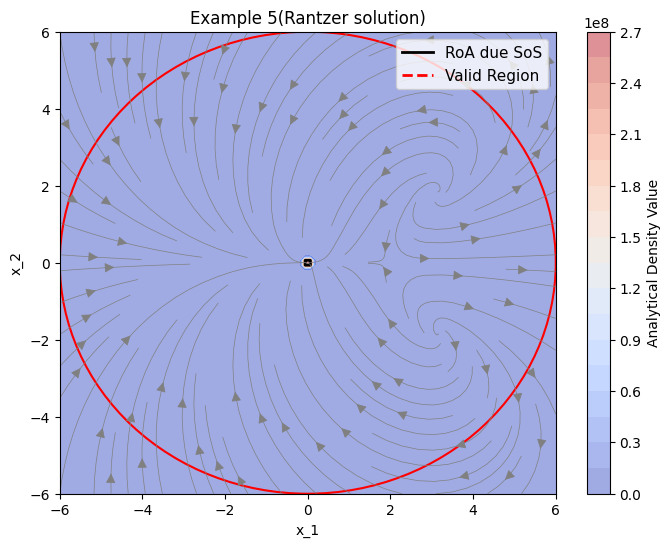

(<Figure size 800x600 with 2 Axes>,
 <Axes: title={'center': 'Example 5(Rantzer solution)'}, xlabel='x_1', ylabel='x_2'>)

In [17]:
print("Plotting Analytical Solution...")
plot_analytical_density_and_flow(1e-8,device, plot_flow=True)


In [34]:

# --- 3. Function to plot Mixed (Learned + Analytical) Density and Flow ---

def plot_mixed_learned_analytical_contours(a_nn, b_nn, c_nn, a_nn1, b_nn1, c_nn1, device, analytical_weight=1.0, plot_flow=True):
    """ 
    Plots the contours of a mixed density (Learned + Analytical) and 
    the flow field of the corresponding mixed control policy.
    """
    # create meshgrid
    x1 = torch.linspace(-6, 6, 100)
    x2 = torch.linspace(-6, 6, 100)
    X, Y = np.meshgrid(x1,x2)
    
    # Convert to torch tensor
    grid_points = torch.tensor(np.column_stack([X.ravel(), Y.ravel()]), dtype=torch.float32).to(device)
    
    # compute the modified density function
    with torch.no_grad():
        # rho_1 (Learned)
        rho_set1 = a_nn(grid_points) / (torch.exp( torch.sum(grid_points**2, dim=1, keepdim=True) + torch.sum((b_nn(grid_points))**2, dim=1, keepdim=True)))
        
        # rho_2 (Analytical)
        rho_set2 = analytical_density(grid_points, device).unsqueeze(1) # Ensure shape [N, 1]

        rho_set3 =  a_nn1(grid_points) / (torch.exp( torch.sum(grid_points**2, dim=1, keepdim=True) + torch.sum((b_nn1(grid_points))**2, dim=1, keepdim=True)))
        rho_set1 = rho_set1 / max(rho_set1)
        rho_set2 = rho_set2 / max(rho_set2)
        rho_set3 = rho_set3 / max(rho_set3)
        # rho_mixed = rho_1 + weight * rho_2
        rho_set = rho_set1 +  rho_set2 + rho_set3
        rho_set = rho_set.squeeze()
        rho_set = rho_set.cpu().numpy().reshape(X.shape)

        # mixed rho
        mixed_rho_set = rho_set1 + rho_set3
        mixed_rho_set = mixed_rho_set.squeeze()
        mixed_rho_set = mixed_rho_set.cpu().numpy().reshape(X.shape)

        rho_set1 = rho_set1.squeeze()
        rho_set3 = rho_set3.squeeze()
        rho_set1 = rho_set1.cpu().numpy().reshape(X.shape)
        rho_set3 = rho_set3.cpu().numpy().reshape(X.shape)
        
    # plot the density function
    fig, ax = plt.subplots(figsize=(8, 6))
    
    ax.contour(X,Y,rho_set1-1e-8,levels=0,colors='magenta', linewidths=2,linestyles='dashed', label='Learned Density ')
    ax.contour(X,Y,rho_set3-1e-8,levels=0,colors='green', linewidths=2,linestyles='dashed', label='Learned Density 2 ')
    
    ax.contour(X,Y,mixed_rho_set-1e-8, levels=0,
                                       colors='blue', linewidths=2, 
                                       linestyles='solid', label='Learned Density ROA')
    
    ax.contour(X,Y,rho_set-1e-8,levels=0,colors='black', linewidths=2,linestyles='solid', label='Mixed Density + SoS ')
    filled_contours = ax.contourf(X, Y, rho_set, levels=20, alpha=0.3, cmap=cm.coolwarm)
    plt.colorbar(filled_contours, label='Mixed Density Value')
    
    if plot_flow:
        # create coarser grid for flow field
        x1_flow = np.linspace(-6, 6, 20)
        x2_flow = np.linspace(-6, 6, 20)
        X_flow, Y_flow = np.meshgrid(x1_flow, x2_flow)
        flow_points = torch.tensor(np.column_stack([X_flow.ravel(), Y_flow.ravel()]), dtype=torch.float32).to(device)
        
        # evaluate control policy u
        with torch.no_grad():
            # rho_1 and u_1 (Learned)
            rho1_flow = 100*a_nn(flow_points) / (torch.exp( torch.sum(flow_points**2, dim=1, keepdim=True) + torch.sum((b_nn(flow_points))**2, dim=1, keepdim=True)))
            u1_flow = c_nn(flow_points) / (a_nn(flow_points) ) # Add epsilon
            
            # rho_2 and u_2 (Analytical)
            rho2_flow = (1e-9)*analytical_density(flow_points, device).unsqueeze(1) # Shape [N, 1]
            u2_flow = analytical_control(flow_points, device).unsqueeze(1)   # Shape [N, 1]

            rho3_flow = 100 * a_nn1(flow_points) / (torch.exp( torch.sum(flow_points**2, dim=1, keepdim=True) + torch.sum((b_nn1(flow_points))**2, dim=1, keepdim=True)))
            u3_flow = c_nn1(flow_points) / (a_nn1(flow_points) ) # Add epsilon

            # Weighted densities
            rho1_weighted = rho1_flow / max(rho1_flow)
            rho2_weighted = rho2_flow / max(rho2_flow)
            rho3_weighted = rho3_flow / max(rho3_flow)
            
            # Total mixed density
            total_rho = rho1_weighted + rho2_weighted + rho3_weighted  # Add epsilon
            
            # Calculate weights
            weight1 = rho1_weighted / total_rho
            weight2 = rho2_weighted / total_rho
            weight3 = rho3_weighted / total_rho
            
            # Mixed control policy: u = w1*u1 + w2*u2
            u_values = weight1 * u1_flow + weight2 * u2_flow + weight3 * u3_flow
                                    
            # Calculate vector field
            DX = np.zeros_like(X_flow)
            DY = np.zeros_like(Y_flow)
            
            for i in range(len(x1_flow)):
                for j in range(len(x2_flow)):
                    idx = i * len(x1_flow) + j # Corrected index calculation
                    x_tensor = torch.tensor([X_flow[i, j], Y_flow[i, j]], device=device, dtype=torch.float32)

                    f_val = f(x_tensor)
                    g_val = g(x_tensor)
                    u = u_values[idx]
                    
                    # Compute flow: f(x) + g(x)u
                    flow = f_val + g_val * u
                    DX[i, j] = flow[0].cpu().numpy()
                    DY[i, j] = flow[1].cpu().numpy()
                    
            # Normalize vectors for better visualization
            magnitude = np.sqrt(DX**2 + DY**2) + 1e-9 # Avoid division by zero
            DX_norm = DX / magnitude
            DY_norm = DY / magnitude
            
            # Plot flow field
            ax.streamplot(X_flow, Y_flow, DX_norm, DY_norm, color='gray', linewidth=0.5,
                          density=1.0, arrowstyle='-|>', arrowsize=1.5)
            
    # Add valid region circle
    circle = plt.Circle((0, 0), 6, color='r', fill=False, linewidth=1.5, linestyle='--',label='Valid Region')
    ax.add_artist(circle)
    
        # Customize plot
    ax.set_xlabel('x1')
    ax.set_ylabel('x2')
    # ax.set_title(f'Example 5(Mixed Density + rantzer solution)')
    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], color='magenta', linewidth=2, linestyle='--', label='Neural Density Controller 1'),
        Line2D([0], [0], color='green', linewidth=2, linestyle='--', label='Neural Density Controller 2'),
        Line2D([0], [0], color='blue', linewidth=2, linestyle='-', label='Mixed Density Controller'),
        Line2D([0], [0], color='black', linewidth=2, linestyle='-', label='Mixed Density + Rantzer Solution'),
        Line2D([0], [0], color='red', linewidth=2, linestyle='--', label='Valid Region')
    ]
    ax.legend(handles=legend_elements, loc='upper right', fontsize=11)
    
    
    plt.show()
    return fig, ax


/tmp/ipykernel_9060/2548416532.py:46: UserWarning: The following kwargs were not used by contour: 'label'
  ax.contour(X,Y,rho_set1-1e-8,levels=0,colors='magenta', linewidths=2,linestyles='dashed', label='Learned Density ')
/tmp/ipykernel_9060/2548416532.py:47: UserWarning: The following kwargs were not used by contour: 'label'
  ax.contour(X,Y,rho_set3-1e-8,levels=0,colors='green', linewidths=2,linestyles='dashed', label='Learned Density 2 ')
/tmp/ipykernel_9060/2548416532.py:49: UserWarning: The following kwargs were not used by contour: 'label'
  ax.contour(X,Y,mixed_rho_set-1e-8, levels=0,
/tmp/ipykernel_9060/2548416532.py:53: UserWarning: The following kwargs were not used by contour: 'label'
  ax.contour(X,Y,rho_set-1e-8,levels=0,colors='black', linewidths=2,linestyles='solid', label='Mixed Density + SoS ')


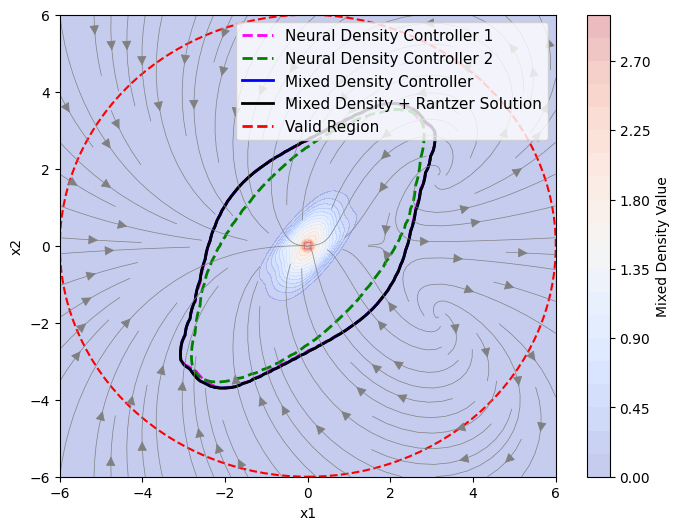

(<Figure size 800x600 with 2 Axes>, <Axes: xlabel='x1', ylabel='x2'>)

In [35]:
plot_mixed_learned_analytical_contours( a_net, b_net, c_net, a_net1, b_net1, c_net1, device, analytical_weight=1.0, plot_flow=True)

# Neural Lyapunov Control:
The key idea is, for asymptotic stability,
\begin{align}
    V(0)=0, \forall x \in D/ \{0\}, V(x)>0 \text{ and } L_{f_u}V(x)<0
\end{align}
where, $L_{f_u}V(x) = \sum_{i=1}^{n} \frac{\partial V}{\partial x_i}[f_u]_i(x)$


In [20]:

# ---------------------------------------------------------------------
# dReal constraint checker
# ---------------------------------------------------------------------
def checkSMTLyapunovconstraints(vars, Lie_derivative, ball_lb, ball_ub, config, epsilon=0):
    ball = Expression(0)
    for i in range(len(vars)):
        ball += vars[i]**2
    ball_in_bound = logical_and(ball >= ball_lb, ball <= ball_ub)
    
    divergence_condition = Lie_derivative < 0
    stability_condition = logical_imply(ball_in_bound, divergence_condition)
    
    return CheckSatisfiability(logical_not(stability_condition), config)

# ---------------------------------------------------------------------
# Add counterexamples (unchanged)
# ---------------------------------------------------------------------
def AddCounterexamples(x, CE, N, device):
    # Detach x from the computational graph to avoid gradient issues
    x = x.detach()
    
    nearby = []
    for i in range(CE.size()):
        lb = CE[i].lb()
        ub = CE[i].ub()
        nearby_ = np.random.uniform(lb, ub, N)
        nearby.append(nearby_)

    for i in range(N):
        n_pt = [nearby[j][i] for j in range(x.shape[1])]
        n_pt_tensor = torch.tensor([n_pt], dtype=torch.float32, device=device)
        x = torch.cat((x, n_pt_tensor), dim=0)
        x = torch.unique(x, dim=0)
    return x, n_pt_tensor


In [21]:
class Lyapunov_net(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(Lyapunov_net, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, output_dim),
            nn.Softplus()  # Ensure positivity
        )
        self._initialize_weights()
    def _initialize_weights(self):
        for layer in self.net:
            if isinstance(layer, nn.Linear):
                nn.init.xavier_uniform_(layer.weight)
                nn.init.zeros_(layer.bias)

    def forward(self, x):
        return self.net(x)

In [22]:
def lyapunov_risk(x, f_fun, V_net, device):
    x = x.to(device)
    x.requires_grad_(True)  
    V_val = V_net(x)
    f_val = f_fun(x)
    grad_V = torch.autograd.grad(V_val.sum(), x, create_graph=True)[0]
    lie_derivative = torch.sum(grad_V * f_val, dim=1, keepdim=True)
    risk = torch.relu(lie_derivative).mean()  # Penalize if V_dot > 0
    # error at the origin, i.e V(0) should be 0
    V_origin = V_net(torch.zeros(1, x.shape[1], device=device))
    risk += V_origin.mean()
    return risk

def lie_derivative_val(x, f_fun, V_net, device):
    x = x.to(device)
    x.requires_grad_(True)  
    V_val = V_net(x)
    f_val = f_fun(x)
    grad_V = torch.autograd.grad(V_val.sum(), x, create_graph=True)[0]
    lie_derivative = torch.sum(grad_V * f_val, dim=1, keepdim=True)
    return lie_derivative


In [23]:
class LyapunovSymbolicNN:
    """A helper class to conver neural networks to symbolic expressions for dReal.
    """
    def __init__(self, net):
        """Initialize with a PyTorch neural network"""
        self.weights = []
        self.biases = []
        self.extract_params(net)

    def extract_params(self, net):
        """Extract weights and biases from PyTorch network"""
        for layer in net.net:
            if isinstance(layer, nn.Linear):
                self.weights.append(layer.weight.detach().cpu().numpy())
                if layer.bias is not None:
                    self.biases.append(layer.bias.detach().cpu().numpy())
    def forward_symbolic(self, vars):
        """
        Compute symbolic forward pass.
        Args:
            vars: List of dReal Variables
        Returns:
            Symbolic expression for network output
        """
        z = vars
        for i in range(len(self.weights)-1):
            # Linear transformation
            z = self._linear_symbolic(z, self.weights[i], self.biases[i])
            # # Apply tanh activation
            z = [tanh(zi) for zi in z]

        # final linear layer with softplus activation
        z = self._linear_symbolic(z, self.weights[-1], self.biases[-1])
        z = [log(1 + exp(zi)) for zi in z]
        return z
    
    def _linear_symbolic(self, x, weight, bias):
        """
        Compute symbolic linear transformation.
        Args:
            x: Input symbolic expressions
            weight: Weight matrix
            bias: Bias vector
        Returns:
            List of symbolic expressions
        """
        out = []
        for i in range(weight.shape[0]):  # For each output dimension
            expr = bias[i]
            for j in range(weight.shape[1]):  # For each input dimension
                expr += weight[i,j] * x[j]
            out.append(expr)
        return out


In [24]:
def candidate_lyapunov_constraint(vars,v_net):
    """ 
    Construct candidate constraints for the learnt functions.

    Args:
        vars: List of dReal Variables
        V_net: fundtion representing V(x)
    Returns:
        Symbolic expression for the candidate constraint which is just lie derivative
    """
    V_sym = LyapunovSymbolicNN(v_net).forward_symbolic(vars)[0]
    f_val = f_val = [-2*vars[0]+vars[0]**2 - vars[1]**2, -6*vars[1]+2*vars[0]*vars[1]]

    grad_v = [V_sym.Differentiate(vars[i]) for i in range(len(vars))]

    constraint = [f_val[i] * grad_v[i] for i in range(len(vars)) ]
    constraint = sum(constraint[i] for i in range(len(constraint)))

    return constraint
    


In [25]:
config = Config()
config.use_polytope_in_forall = True
config.use_local_optimization = True
config.precision = 1e-5
epsilon = 0

ball_lb = 0.5
ball_ub = 6
x1 = Variable("x1")
x2 = Variable("x2")


In [26]:
def train_lyapunov(x,epochs=2000,lr=1e-2):
    loss_lyapunov = []
    V_net = Lyapunov_net(2,6,1).to(device)

    optimizer = torch.optim.Adam(V_net.parameters(),lr=lr)
    valid = False
    print("Training Lyapunov Function")
    while not valid:
        for epoch in range(epochs):
            optimizer.zero_grad()
            loss = lyapunov_risk(x,f,V_net,device=device)
            loss_lyapunov.append(loss.item())
            loss.backward()
            optimizer.step()
            print(f"Epoch {epoch}/{epochs}, Loss: {loss.item():.4f}")
            if loss.item() < 3e-4:
                valid = True
                print("No counterexample found.")
                break

            if epoch%100 == 0:
                vars = [Variable("x1"), Variable("x2")]
                lie_derivative = candidate_lyapunov_constraint(vars, V_net)
                CE = checkSMTLyapunovconstraints(vars,lie_derivative, ball_lb, ball_ub, config)
                if (CE):
                    print("Counterexample found!")
                    x, n_pt_tensor = AddCounterexamples(x, CE, 100, device)
                else:
                    valid = True 
                    print("No counterexample found.")
                    break

    print(f"Final Loss: {loss.item():.4f}")
    return loss_lyapunov, V_net

In [27]:
loss_lyapunov, V_net = train_lyapunov(numerical_x, epochs=4000, lr=1e-3)

Training Lyapunov Function
Epoch 0/4000, Loss: 1.1098
Counterexample found!
Epoch 1/4000, Loss: 1.0564
Epoch 2/4000, Loss: 1.0375
Epoch 3/4000, Loss: 1.0193
Epoch 4/4000, Loss: 1.0019
Epoch 5/4000, Loss: 0.9851
Epoch 6/4000, Loss: 0.9686
Epoch 7/4000, Loss: 0.9529
Epoch 8/4000, Loss: 0.9374
Epoch 9/4000, Loss: 0.9223
Epoch 10/4000, Loss: 0.9076
Epoch 11/4000, Loss: 0.8933
Epoch 12/4000, Loss: 0.8793
Epoch 13/4000, Loss: 0.8658
Epoch 14/4000, Loss: 0.8528
Epoch 15/4000, Loss: 0.8402
Epoch 16/4000, Loss: 0.8279
Epoch 17/4000, Loss: 0.8160
Epoch 18/4000, Loss: 0.8045
Epoch 19/4000, Loss: 0.7934
Epoch 20/4000, Loss: 0.7828
Epoch 21/4000, Loss: 0.7726
Epoch 22/4000, Loss: 0.7628
Epoch 23/4000, Loss: 0.7534
Epoch 24/4000, Loss: 0.7443
Epoch 25/4000, Loss: 0.7355
Epoch 26/4000, Loss: 0.7270
Epoch 27/4000, Loss: 0.7186
Epoch 28/4000, Loss: 0.7111
Epoch 29/4000, Loss: 0.7045
Epoch 30/4000, Loss: 0.6981
Epoch 31/4000, Loss: 0.6919
Epoch 32/4000, Loss: 0.6858
Epoch 33/4000, Loss: 0.6800
Epoch 34/

KeyboardInterrupt: 

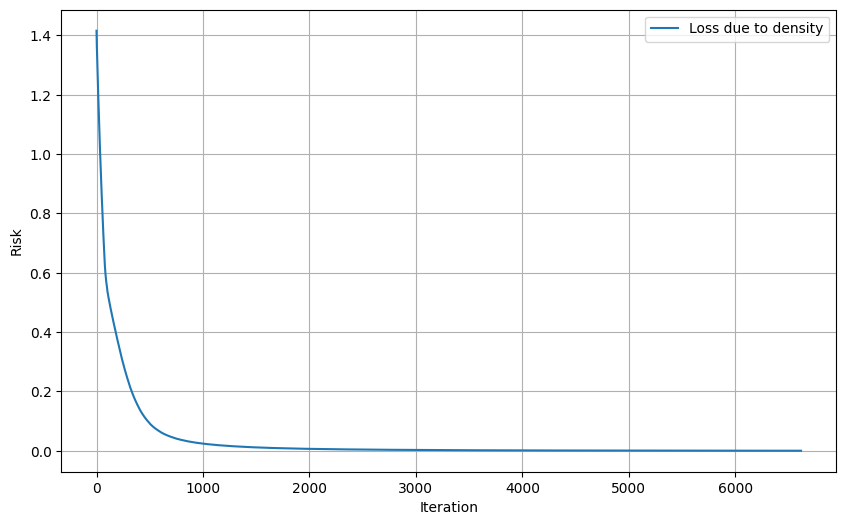

In [118]:

risks = []
risks.append(loss_lyapunov)

plot_results(risks, labels=[f"Loss due to {d}" for d in ['density']])


In [119]:
grid_size = 100
# Define grid for x1 and x2
x1 = torch.linspace(-6, 6, grid_size)
x2 = torch.linspace(-6, 6, grid_size)
x1_grid, x2_grid = torch.meshgrid(x1, x2)
grid_points = torch.stack([x1_grid.ravel(), x2_grid.ravel()], dim=1).to(device)


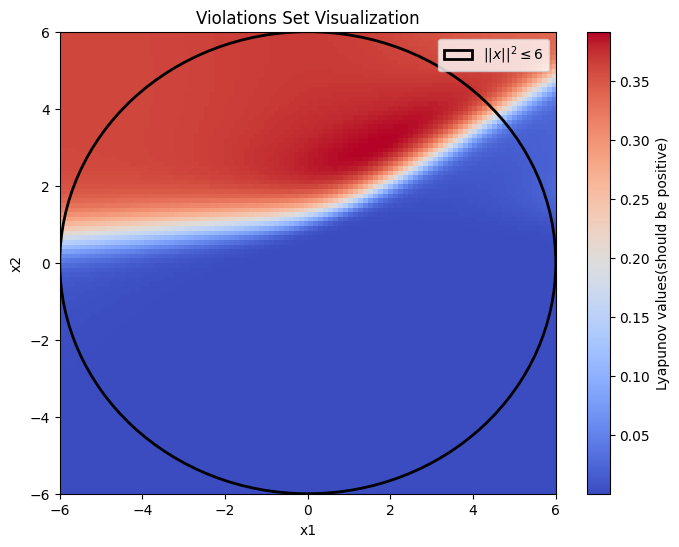

In [120]:
V_set = V_net(grid_points)
violations_set = V_set.detach().cpu().numpy().reshape(grid_size, grid_size)

import matplotlib.patches as patches

# Plot heatmap
plt.figure(figsize=(8, 6))
plt.imshow(
    violations_set,
    extent=[-6, 6, -6, 6],
    origin='lower',
    cmap='coolwarm',
    aspect='auto'
)
plt.colorbar(label="Lyapunov values(should be positive)")
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Violations Set Visualization")

# Add a circle to the plot
circle = patches.Circle((0, 0), 6, color='black', fill=False, linewidth=2, label="$||x||^2 \leq 6$")
plt.gca().add_patch(circle)

# Add legend for the circle
plt.legend(loc='upper right')

plt.grid(False)
plt.show()



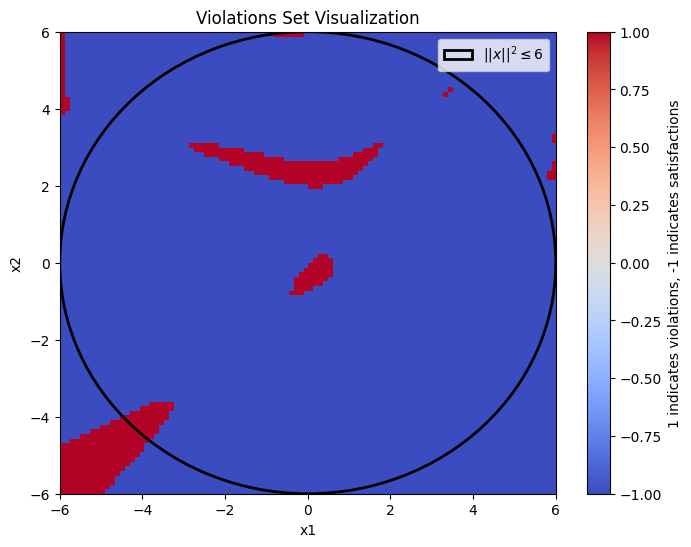

In [121]:
lie_derivatives = lie_derivative_val(grid_points,f,V_net,device)
violations_set = lie_derivatives
# # Convert to binary values: 1 for violation, -1 for satisfaction
violations_set = torch.where(violations_set >= 0, 1, -1)


# Move to CPU and convert to NumPy for visualization
violations_set = violations_set.detach().cpu().numpy().reshape(grid_size, grid_size)




import matplotlib.patches as patches

# Plot heatmap
plt.figure(figsize=(8, 6))
plt.imshow(
    violations_set,
    extent=[-6, 6, -6, 6],
    origin='lower',
    cmap='coolwarm',
    aspect='auto'
)
plt.colorbar(label="1 indicates violations, -1 indicates satisfactions")
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Violations Set Visualization")

# Add a circle to the plot
circle = patches.Circle((0, 0), 6, color='black', fill=False, linewidth=2, label="$||x||^2 \leq 6$")
plt.gca().add_patch(circle)

# Add legend for the circle
plt.legend(loc='upper right')

plt.grid(False)
plt.show()


In [122]:
torch.save(V_net.state_dict(), 'learnt_lyapunov_example_5.pth')

In [123]:
torch.manual_seed(7)
random.seed()
numerical_x = torch.Tensor(1000, 2).uniform_(-6, 6).float()
numerical_x = numerical_x.to(device)

loss_lyapunov, V_net = train_lyapunov(numerical_x, epochs=4000, lr=1e-3)

Training Lyapunov Function
Epoch 0/4000, Loss: 2.3996
Counterexample found!
Epoch 1/4000, Loss: 2.3583
Epoch 2/4000, Loss: 2.3240
Epoch 3/4000, Loss: 2.2899
Epoch 4/4000, Loss: 2.2560
Epoch 5/4000, Loss: 2.2222
Epoch 6/4000, Loss: 2.1886
Epoch 7/4000, Loss: 2.1551
Epoch 8/4000, Loss: 2.1219
Epoch 9/4000, Loss: 2.0889
Epoch 10/4000, Loss: 2.0563
Epoch 11/4000, Loss: 2.0239
Epoch 12/4000, Loss: 1.9919
Epoch 13/4000, Loss: 1.9603
Epoch 14/4000, Loss: 1.9291
Epoch 15/4000, Loss: 1.8981
Epoch 16/4000, Loss: 1.8673
Epoch 17/4000, Loss: 1.8370
Epoch 18/4000, Loss: 1.8068
Epoch 19/4000, Loss: 1.7771
Epoch 20/4000, Loss: 1.7475
Epoch 21/4000, Loss: 1.7183
Epoch 22/4000, Loss: 1.6896
Epoch 23/4000, Loss: 1.6614
Epoch 24/4000, Loss: 1.6339
Epoch 25/4000, Loss: 1.6068
Epoch 26/4000, Loss: 1.5798
Epoch 27/4000, Loss: 1.5530
Epoch 28/4000, Loss: 1.5263
Epoch 29/4000, Loss: 1.4998
Epoch 30/4000, Loss: 1.4738
Epoch 31/4000, Loss: 1.4487
Epoch 32/4000, Loss: 1.4240
Epoch 33/4000, Loss: 1.3998
Epoch 34/

In [124]:
torch.save(V_net.state_dict(), 'learnt_lyapunov1_example_5.pth')

In [28]:
INPUT_DIM = 2
HIDDEN_DIM = 6
OUTPUT_DIM = 1

In [29]:
v_net = Lyapunov_net(INPUT_DIM, HIDDEN_DIM, OUTPUT_DIM).to(device)
v_net.load_state_dict(torch.load('Model_Paths/learnt_lyapunov_example_5.pth', map_location=device))
v_net.eval()

v_net1 = Lyapunov_net(INPUT_DIM, HIDDEN_DIM, OUTPUT_DIM).to(device)
v_net1.load_state_dict(torch.load('Model_Paths/learnt_lyapunov1_example_5.pth', map_location=device))
v_net1.eval()

/tmp/ipykernel_9060/1852701083.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  v_net.load_state_dict(torch.load('Model_Paths/learnt_lyapunov_example_5.pth', map_location

Lyapunov_net(
  (net): Sequential(
    (0): Linear(in_features=2, out_features=6, bias=True)
    (1): Tanh()
    (2): Linear(in_features=6, out_features=6, bias=True)
    (3): Tanh()
    (4): Linear(in_features=6, out_features=1, bias=True)
    (5): Softplus(beta=1.0, threshold=20.0)
  )
)

In [30]:
def plot_lyapunov_contours(V_net,lyapunov_threshold,device,plot_flow=True):
    x1 = torch.linspace(-6, 6, 100)
    x2 = torch.linspace(-6, 6, 100)
    X, Y = np.meshgrid(x1,x2)

    # Convert to torch tensor
    grid_points = torch.tensor(np.column_stack([X.ravel(), Y.ravel()]), dtype=torch.float32).to(device)

    with torch.no_grad():
        l_vals = V_net(grid_points)
        l_vals = l_vals.squeeze()
        l_vals = l_vals.cpu().numpy().reshape(X.shape)

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.contour(X,Y,l_vals,levels=[lyapunov_threshold],colors='black', linewidths=2,linestyles='solid', label='Lyapunov')
    filled_contours = ax.contourf(X, Y, l_vals, levels=10, alpha=0.3, cmap=cm.coolwarm)
    plt.colorbar(filled_contours, label='Lyapunov Value')
    if plot_flow:
        # create coarser grid for flow field
        x1_flow = np.linspace(-6, 6, 20)
        x2_flow = np.linspace(-6, 6, 20)
        X_flow, Y_flow = np.meshgrid(x1_flow, x2_flow)
        flow_points = torch.tensor(np.column_stack([X_flow.ravel(), Y_flow.ravel()]), dtype=torch.float32).to(device)

        # evaluate control policy u
        with torch.no_grad():
            l_vals = V_net(flow_points)
        
        DX = np.zeros_like(X_flow)
        DY = np.zeros_like(Y_flow)

        for i in range(len(x1_flow)):
            for j in range(len(x2_flow)):
                x = torch.tensor([X_flow[i, j], Y_flow[i, j]], device=device)
                f_val = f(x)
        
                flow = f_val 
                DX[i, j] = flow[0].cpu().numpy()
                DY[i, j] = flow[1].cpu().numpy()
        # Normalize vectors for better visualization
        magnitude = np.sqrt(DX**2 + DY**2)
        DX = DX / magnitude
        DY = DY / magnitude
        
        # Plot flow field
        ax.streamplot(X_flow, Y_flow, DX, DY, color='gray', linewidth=0.5,
                     density=1.0, arrowstyle='-|>', arrowsize=1.5)
    circle = plt.Circle((0, 0), 6, color='r', fill=False, linewidth=1.5, label='Valid Region')
    ax.add_artist(circle)
    ax.set_xlabel('x_1', fontsize=12)
    ax.set_ylabel('x_2', fontsize=12)
    ax.set_title('Example 5')
    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], color='black', linewidth=2, linestyle='-', label='Neural Lyapunov Controller'),
        Line2D([0], [0], color='red', linewidth=2, linestyle='--', label='Valid Region')
    ]
    ax.legend(handles=legend_elements, loc='upper right', fontsize=11)
    
    
    
    plt.show()
    
    return fig, ax



/tmp/ipykernel_9060/601548681.py:15: UserWarning: The following kwargs were not used by contour: 'label'
  ax.contour(X,Y,l_vals,levels=[lyapunov_threshold],colors='black', linewidths=2,linestyles='solid', label='Lyapunov')


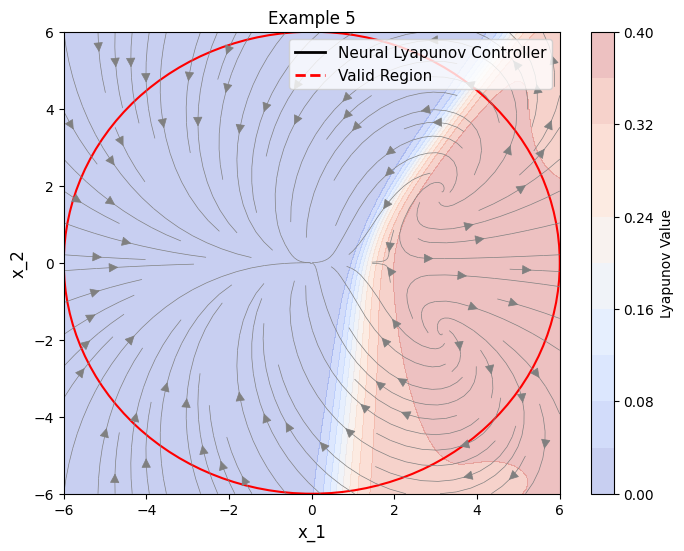

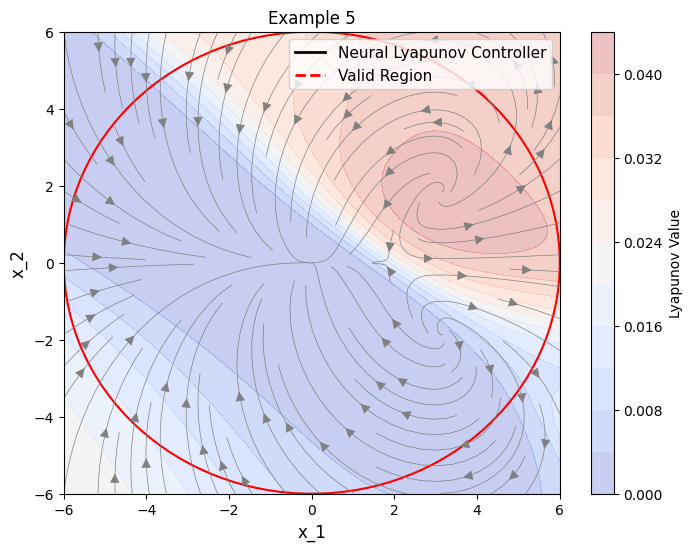

(<Figure size 800x600 with 2 Axes>,
 <Axes: title={'center': 'Example 5'}, xlabel='x_1', ylabel='x_2'>)

In [31]:
plot_lyapunov_contours(v_net,0.523,device,plot_flow=True)
plot_lyapunov_contours(v_net1,0.27,device,plot_flow=True)
